# 00 — How many coin tosses?

You are handed a coin. You suspect its bias has changed. **How many tosses do you need?**

That question has no single answer, and the ways it fails to have one are the subject of this
project. This notebook answers it three times — with an exact fixed-sample test, with a
sequential detector, and in seconds rather than tosses — and then shows that the innocuous
question *"does the starting probability matter?"* has **opposite answers** depending on a
modelling choice most people make without noticing.

A single-shot quantum measurement **is** a Bernoulli observation, so none of this is analogy.
By notebook 02 the coin will be a quantum sensor and nothing in the mathematics will change.

---

**How to read the conclusions.** This notebook is a *pedagogical view*, never a source of
evidence. Every boxed conclusion is labelled:

| label | meaning |
|---|---|
| `textbook` | a standard statistical result, not a claim of this project |
| `result` / `pilot` / `open` / `withdrawn` | a claim in `ledgers/status.yaml`, linked by id |

Numbers here are computed live from `analysis/lib`, the same tested code the research runs use.
Nothing in `analysis/outputs/` or `figures/` is read as input or written as output.

In [1]:
import math, sys, os
from pathlib import Path

import numpy as np
from scipy.stats import binom
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Import the project's tested functions rather than restating the formulas here.
# Normally the notebook is opened from tutorials/, so walking up from the working directory
# finds the repository. SID_ROOT overrides that, which is how the test executes this notebook
# from a temporary directory outside the tree.
ROOT = Path(os.environ["SID_ROOT"]) if os.environ.get("SID_ROOT") else Path.cwd()
while not (ROOT / "analysis" / "lib").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "analysis" / "lib").is_dir():
    raise RuntimeError("run this notebook from inside the repository, or set SID_ROOT")
sys.path.insert(0, str(ROOT / "analysis" / "lib"))
from sid_lib import DB, INK, SEA, SIG, STONE, PARCH   # DB = Bernoulli divergence

plt.rcParams.update({"font.family": "serif", "figure.dpi": 130})
SEED = 20260905           # every random result below is reproducible from this

# sid_lib selects the Agg backend on import, which disables the inline formatter, so figures
# are rendered explicitly. IPython is optional: without it the notebook still runs top to
# bottom (that is how the test executes it), it simply draws nothing.
import io
try:
    from IPython.display import Image, display
    _INLINE = True
except ImportError:
    _INLINE = False

def show(fig):
    if _INLINE:
        buf = io.BytesIO(); fig.savefig(buf, format="png", bbox_inches="tight")
        display(Image(data=buf.getvalue()))
    plt.close(fig)
print("project root:", ROOT.name)
print("numpy", np.__version__)

project root: signals-in-darkness
numpy 2.2.4


## 1. State the question properly

"Is the coin biased?" is not yet answerable. Five things must be fixed first:

| symbol | meaning |
|---|---|
| $p_0$ | the probability of heads you are testing **against** |
| $p_1$ | the alternative you want to be able to detect |
| $\alpha$ | the false-alarm probability you will tolerate |
| $1-\beta$ | the power — the chance of catching a real change |
| — | whether the change time is **known** (fixed-sample) or **unknown** (sequential) |

That last row is the one that changes the shape of the answer, and it is the one usually left
implicit.

In [2]:
p0, p1 = 0.5, 0.6          # fair coin -> 60% heads
alpha, power = 0.05, 0.90

D = DB(p1, p0)             # Bernoulli divergence, nats per toss
print(f"p0 = {p0}   p1 = {p1}   alpha = {alpha}   power = {power}")
print(f"\nD(p1 || p0) = {D:.6f} nats per toss")
print(f"1/D         = {1/D:.1f} tosses")

p0 = 0.5   p1 = 0.6   alpha = 0.05   power = 0.9

D(p1 || p0) = 0.020136 nats per toss
1/D         = 49.7 tosses


The divergence is the **information per toss** that distinguishes the two coins, and $1/D$ is
the natural scale of the problem: roughly fifty tosses. Every answer below is some multiple of
that number, and understanding *which* multiple, and why, is most of the subject.

The log-likelihood ratio of a single toss is

$$\ell(y)=\log\frac{P_1(y)}{P_0(y)}=\begin{cases}\log(p_1/p_0) & y=\text{heads}\\[2pt]\log\frac{1-p_1}{1-p_0} & y=\text{tails}\end{cases}$$

and $D$ is exactly its mean under $P_1$.

In [3]:
l_head, l_tail = math.log(p1/p0), math.log((1-p1)/(1-p0))
print(f"log-likelihood ratio: heads {l_head:+.4f}   tails {l_tail:+.4f} nats")
print(f"mean under P1 = {p1*l_head + (1-p1)*l_tail:.6f}  ==  D = {D:.6f}")

log-likelihood ratio: heads +0.1823   tails -0.2231 nats
mean under P1 = 0.020136  ==  D = 0.020136


## 2. Fixed sample: the exact binomial test

If the coin either was or was not biased for the whole run, toss it $n$ times and count heads.
No normal approximation — the exact binomial tail.

In [4]:
def fixed_sample_n(p0, p1, alpha, power, nmax=5000):
    """Smallest n whose exact one-sided binomial test has the required level and power."""
    for n in range(1, nmax):
        k = int(binom.ppf(1 - alpha, n, p0))
        while binom.sf(k, n, p0) > alpha:      # keep alpha a true upper bound
            k += 1
        if binom.sf(k, n, p1) >= power:
            return n, k, binom.sf(k, n, p0), binom.sf(k, n, p1)
    raise RuntimeError("no n found")

n_fixed, k_crit, a_actual, power_actual = fixed_sample_n(p0, p1, alpha, power)
print(f"n = {n_fixed} tosses; declare bias if heads > {k_crit}")
print(f"  actual false-alarm rate {a_actual:.4f} (<= {alpha})")
print(f"  actual power            {power_actual:.4f} (>= {power})")
print(f"  in units of 1/D: {n_fixed*D:.2f}")

n = 213 tosses; declare bias if heads > 118
  actual false-alarm rate 0.0499 (<= 0.05)
  actual power            0.9028 (>= 0.9)
  in units of 1/D: 4.29


> **`textbook`** — 213 tosses, about $4.3/D$. The factor of four over the information scale is
> the price of the two error probabilities you demanded.

## 3. Sequential: a calibrated CUSUM

Now the change happens at an unknown time and you want to notice it *soon*. Accumulate the
log-likelihood ratio, floor it at zero, and alarm when it crosses $h$:

$$W_n=\max(0,\;W_{n-1}+\ell(y_n)),\qquad \text{alarm when } W_n\ge h.$$

The floor is what makes it sequential: evidence for "no change" is discarded rather than banked,
so an old quiet stretch cannot mask a new change.

Calibration is by *false-alarm rate*, not by a p-value. We set the mean time between false
alarms — the null run length $\mathbb{E}_0[T]$ — to $n/\alpha$, which is the rate you would incur
by repeating the fixed-sample test forever.

In [5]:
def cusum(p, h, runs, seed, cap=60_000):
    """Vectorised CUSUM stopping times for `runs` independent streams at bias p."""
    rng = np.random.default_rng(seed)
    W = np.zeros(runs); stop = np.full(runs, cap); live = np.ones(runs, bool)
    for step in range(cap):
        y = rng.random(runs) < p
        W = np.maximum(0.0, W + np.where(y, l_head, l_tail))
        hit = live & (W >= h); stop[hit] = step + 1; live &= ~hit
        if not live.any():
            break
    return stop

target_arl0 = n_fixed / alpha
lo, hi = 1.0, 10.0
for _ in range(10):                      # bisection on the threshold
    mid = 0.5 * (lo + hi)
    if cusum(p0, mid, 300, SEED, 60_000).mean() > target_arl0: hi = mid
    else: lo = mid
h = 0.5 * (lo + hi)

arl0  = cusum(p0, h, 600, SEED + 1)
delay = cusum(p1, h, 600, SEED + 2)
print(f"target E0[T] = n/alpha = {target_arl0:.0f}")
print(f"h*           = {h:.3f}")
print(f"measured E0[T] = {arl0.mean():.0f} +- {arl0.std()/math.sqrt(len(arl0)):.0f}")
print(f"\ndetection delay E1[T] = {delay.mean():.1f} +- {delay.std()/math.sqrt(len(delay)):.1f} tosses")
print(f"  first-order prediction h/D = {h/D:.1f}; measured/predicted = {delay.mean()/(h/D):.2f}")
print(f"  martingale bound E0[T] >= e^h = {math.exp(h):.0f}; actual is {arl0.mean()/math.exp(h):.0f}x larger")

target E0[T] = n/alpha = 4260
h*           = 4.371
measured E0[T] = 4522 +- 166

detection delay E1[T] = 174.1 +- 4.2 tosses
  first-order prediction h/D = 217.1; measured/predicted = 0.80
  martingale bound E0[T] >= e^h = 79; actual is 57x larger


> **`textbook`** — the sequential detector notices the change in about 170 tosses on average,
> against 213 for the fixed-sample test, *while tolerating false alarms at the same rate per
> toss*. Sequential analysis is not free; it buys earliness with the assumption that you are
> willing to keep watching.
>
> Two details that recur throughout this project:
>
> - The delay lands at about **0.8 × h/D**, not at $h/D$. The reflecting floor shortens first
>   passage. The same factor appears for the quantum detector — note 01 §7 reports delays at
>   0.8–0.9 of $h/I$ (claim [`C25`](../ledgers/status.yaml), `result`).
> - The martingale bound $\mathbb{E}_0[T]\ge e^{h}$ holds but is far too loose to calibrate with.
>   The project measures how loose in its own setting: claim [`C10`](../ledgers/status.yaml),
>   `result`, finds a factor of $10^2$–$10^4$ for the restarted-SPRT variant. Our simpler CUSUM
>   is looser by a smaller factor — a *different* quantity, not a check of C10.

## 4. Tosses are not seconds

An experiment does not spend tosses, it spends time. If one toss costs $c$ seconds of cycle
time, the comparison changes character: what matters is information **per second**, not per
toss. This is the first place the physics starts to bite, and it is why the project's regime map
has a time axis at all.

In [6]:
for c in (0.001, 0.05, 1.0):
    print(f"cycle time {c:>6} s   fixed sample {n_fixed*c:8.2f} s   sequential {delay.mean()*c:8.2f} s")

cycle time  0.001 s   fixed sample     0.21 s   sequential     0.17 s
cycle time   0.05 s   fixed sample    10.65 s   sequential     8.71 s
cycle time    1.0 s   fixed sample   213.00 s   sequential   174.14 s


## 5. The trap: does the starting probability matter?

Ask "is it easier to detect a change near a fair coin, or near a strongly biased one?" and you
will get a confident answer. The answer is **not determined** until you say what is held fixed.

Two natural choices, both matched at $p_0=0.5$ so they are indistinguishable there:

- a fixed **absolute** change, $p_1=p_0+\Delta p$;
- a fixed change in **log-odds**, $\operatorname{logit}p_1=\operatorname{logit}p_0+\delta$.

at p0 = 0.05: fixed dp gives 0.02065, fixed log-odds gives 0.00108  ->  19x apart
at p0 = 0.02: fixed dp gives 0.03899, fixed log-odds gives 0.00045  ->  87x apart
fixed dp        is maximised at p0 = 0.02, minimised at 0.48
fixed log-odds  is maximised at p0 = 0.47, minimised at 0.02


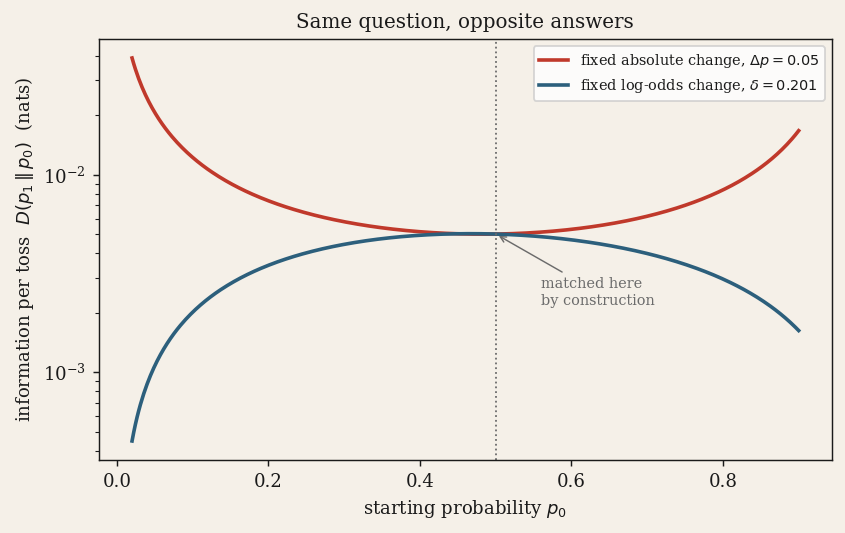

In [7]:
logit = lambda p: math.log(p/(1-p))
expit = lambda x: 1.0/(1.0 + math.exp(-x))

dp = 0.05
delta = logit(0.5 + dp) - logit(0.5)        # matched to dp at p0 = 0.5
grid = np.linspace(0.02, 0.90, 400)
D_abs   = np.array([DB(p + dp, p) for p in grid])
D_odds  = np.array([DB(expit(logit(p) + delta), p) for p in grid])

fig, ax = plt.subplots(figsize=(6.6, 4.2), facecolor=PARCH); ax.set_facecolor(PARCH)
ax.plot(grid, D_abs,  color=SIG, lw=2, label=rf"fixed absolute change, $\Delta p={dp}$")
ax.plot(grid, D_odds, color=SEA, lw=2, label=rf"fixed log-odds change, $\delta={delta:.3f}$")
ax.axvline(0.5, color=STONE, lw=1, ls=":")
ax.annotate("matched here\nby construction", xy=(0.5, D_abs[np.argmin(abs(grid-0.5))]),
            xytext=(0.56, 0.0022), fontsize=8, color=STONE,
            arrowprops=dict(arrowstyle="->", color=STONE, lw=0.8))
ax.set_yscale("log"); ax.set_xlabel(r"starting probability $p_0$")
ax.set_ylabel("information per toss  $D(p_1\\,\\|\\,p_0)$  (nats)")
ax.set_title("Same question, opposite answers", fontsize=11); ax.legend(fontsize=8)
fig.tight_layout()

for probe in (0.05, 0.02):
    a = DB(probe + dp, probe)
    b = DB(expit(logit(probe) + delta), probe)
    print(f"at p0 = {probe:.2f}: fixed dp gives {a:.5f}, fixed log-odds gives {b:.5f}  ->  {a/b:.0f}x apart")
print(f"fixed dp        is maximised at p0 = {grid[D_abs.argmax()]:.2f}, minimised at {grid[D_abs.argmin()]:.2f}")
print(f"fixed log-odds  is maximised at p0 = {grid[D_odds.argmax()]:.2f}, minimised at {grid[D_odds.argmin()]:.2f}")
show(fig)

> **`textbook`** — the two curves run in **opposite directions**. Under a fixed absolute change,
> information is *lowest* near a fair coin and rises sharply toward the edges. Under a fixed
> log-odds change, it is *highest* near a fair coin and collapses at the edges. At $p_0=0.05$ they
> differ by a factor of about **19**, and by about **87** at $p_0=0.02$.
>
> So "does the starting probability matter?" is not a question about coins. It is a question about
> which alternative you meant, and the answer flips with it. Any claim of the form *"operate near
> the edge"* or *"operate near the middle"* is empty until the held-fixed quantity is stated.

This is not a pedantic point. In notebook 02 the two operating points of the quantum sensor sit at
opposite ends of exactly this axis: the dark extremum works at small $p_0$, mid-fringe at
$p_0=1/2$. Which one wins depends on what the physics holds fixed — and the answer is not the same
in every regime, which is the crossover the project exists to map (claim
[`C05`](../ledgers/status.yaml), `result`).

## What we established

| conclusion | label |
|---|---|
| $D(p_1\|p_0)=0.0201$ nats/toss; the problem's scale is $1/D\approx 50$ tosses | `textbook` |
| Exact fixed-sample test: 213 tosses at $\alpha=0.05$, power $0.90$ | `textbook` |
| Calibrated CUSUM detects in ≈171 tosses at the same false-alarm rate per toss | `textbook` |
| Delay $\approx 0.8\,h/D$; the same 0.8–0.9 factor appears in [`C25`](../ledgers/status.yaml) | `result` |
| $\mathbb{E}_0[T]\ge e^h$ is true but too loose to calibrate with; cf. [`C10`](../ledgers/status.yaml) | `result` |
| "Does $p_0$ matter?" has opposite answers under fixed $\Delta p$ and fixed $\Delta$log-odds | `textbook` |

Nothing above is new evidence. The two `result` rows point at claims established elsewhere in
this repository and reproduced under its certified environment; the tutorial only illustrates them.

---

## The question this leaves open

Every calculation above assumed each toss is **independent**. The CUSUM sums log-likelihood
ratios as if no toss knows anything about the last one.

Real hidden biases drift. If the coin's probability wanders slowly, two streams can show *the
same average number of heads* and still be told apart — because one of them remembers.

> **What changes when the coin's probability has a memory of previous tosses?**

That is notebook 01, and it is where Signals in Darkness actually begins.